Solemne 1 - Míneria de Datos: Análisis Económico de América Latina

Este análisis económico es en base a la base de datos presentada por World Bank Open API, llamada 'wbgapi', la cual recopila información de más de 250 países con su indicadores económicos, sociales y financieros. Esta API es de acceso público y vía libreria de Python.

Para este análisis se trabajará con un subconjunto perteneciente a la región de 'América Latina y el Caribe', del cual se eligieron los siguientes países: Brasil, Mexico, Argentina, Colombia, Chile, Perú, Uruguay y Puerto Rico. Además, nos enfocaremos en el período de 1960 al 2025, y los indicadores en los que nos enfocaremos serán "Economy & Growth", "Financial Sector", "Poverty", "Public Sector" y "External Debt". La elección de los países fue en base a su PIB en la región, además de su estabilidad. Adicionalmente, se agregó Puerto Rico con el fin de que pueda servir de comparación con el resto de la región, ya que su situación a nivel político y económico es bastante distinto del resto.

Luego, en temas de hipótesis, tengo las siguientes expectativas:
- Chile debería tener un crecimiento en el PIB relativamente estable comparado con el promedio regional, aun que con caidas en los años 2019 y 2020 por el estallido social y el COVID-19.
- A nivel de correlación, debería existir una relación inversamente proporcional entre el crecimiento del PIB y el desempleo.
- El impacto del COVID-19 en el 2020 debería verse como una caída en la región completa, con una recuperación entre los años 2021 y 2023.
- Viendo mas atrás, deberíamos ver una deuda externa importante en la región por la decada de los 70's y 80's producido por los golpes militares, a excepción de México. Y en el caso particular de Chile, debería existir un aumento en la inflación por la primera mitad de los 70's.

Todo esto será evaluado mas adelante en esta investigación.

Parte 2: Limpieza y Transformación

In [ ]:
pip install wbgapi pandas matplotlib seaborn

In [4]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

#creo lista paises e indicadores
paises = ['BRA', 'MEX', 'ARG', 'COL', 'PER', 'CHL', 'URY', 'PRI']

indicadores = {
    'NY.GDP.MKTP.KD.ZG': 'crecimiento_pib',
    'NY.GDP.PCAP.KD':    'pib_per_capita',
    'FP.CPI.TOTL.ZG':    'inflacion',
    'SL.UEM.TOTL.ZS':    'desempleo',
    'SI.POV.GINI':       'gini',
    'DT.DOD.DECT.GN.ZS': 'deuda_externa',
    'GC.DOD.TOTL.GD.ZS': 'deuda_interna',
}

#creo archivo local por si la API se cae
ARCHIVO = 'datos_latam.csv'

if os.path.exists(ARCHIVO):
    df_raw = pd.read_csv(ARCHIVO)
    print("Datos cargados desde archivo local.")
else:
    df_raw = wb.data.DataFrame(
        list(indicadores.keys()),
        economy=paises,
        time=range(1960, 2024),
        labels=True,
        columns='series'
    ).reset_index()
    df_raw.to_csv(ARCHIVO, index=False)
    print("Datos descargados y guardados en datos_latam.csv")

# Exploración inicial
print(df_raw.shape)
print('=' * 30)
print(df_raw.dtypes)
print('=' * 30)
print(df_raw['Time'].min(), df_raw['Time'].max())
print('=' * 30)
print(df_raw.isnull().sum())
print('=' * 30)
print(df_raw.describe())

Datos descargados y guardados en datos_latam.csv
(512, 11)
economy                  str
time                     str
Country                  str
Time                     str
DT.DOD.DECT.GN.ZS    float64
FP.CPI.TOTL.ZG       float64
GC.DOD.TOTL.GD.ZS    float64
NY.GDP.MKTP.KD.ZG    float64
NY.GDP.PCAP.KD       float64
SI.POV.GINI          float64
SL.UEM.TOTL.ZS       float64
dtype: object
1960 2023
economy                0
time                   0
Country                0
Time                   0
DT.DOD.DECT.GN.ZS    242
FP.CPI.TOTL.ZG       154
GC.DOD.TOTL.GD.ZS    407
NY.GDP.MKTP.KD.ZG      8
NY.GDP.PCAP.KD         0
SI.POV.GINI          314
SL.UEM.TOTL.ZS       248
dtype: int64
       DT.DOD.DECT.GN.ZS  FP.CPI.TOTL.ZG  GC.DOD.TOTL.GD.ZS  \
count         270.000000      358.000000         105.000000   
mean           39.519022       89.521982          49.066643   
std            19.263129      492.764756          27.690994   
min            10.729963        0.193135           5.40391

In [5]:
df_raw.head()

,economy,time,Country,Time,DT.DOD.DECT.GN.ZS,FP.CPI.TOTL.ZG,GC.DOD.TOTL.GD.ZS,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.KD,SI.POV.GINI,SL.UEM.TOTL.ZS
0,PRI,YR2023,Puerto Rico (US),2023,NaN,NaN,NaN,0.731492,30012.924247,NaN,5.725
1,PRI,YR2022,Puerto Rico (US),2022,NaN,NaN,NaN,2.957096,29643.740891,NaN,6.000
2,PRI,YR2021,Puerto Rico (US),2021,NaN,NaN,NaN,0.385223,28416.623126,NaN,7.900
3,PRI,YR2020,Puerto Rico (US),2020,NaN,NaN,NaN,-4.180874,28144.722318,NaN,8.890
4,PRI,YR2019,Puerto Rico (US),2019,NaN,NaN,NaN,1.675464,29185.096996,NaN,8.300


Aquí podemos ver que este conjunto del dataset tiene 512 filas y 11 columnas, de las cuales, las primeras 4 columnas son texto y las 7 restantes son numéricos. Sin embargo, tenemos información importante en la cantidad de nulos, y es que hay bastantes indicadores con un porcentaje importante de valores nulos, como GC.DOD.TOTL.GD.ZS (Deuda Interna) y SI.POV.GINI (Coeficiente de Gini). Esto ocurre ya que, en el caso de la deuda interna, esta información no la compartían los países antes de los años 90, por lo que la información es mas moderna, y el coeficiente de Gini tiene esa cantidad de nulos ya que no se calcula todos los años, sino que de manera intermitente.

En base a eso, aplicaré un filtro temporal en el que trabajaremos desde los años 70's en adelante, ya que anterior a los 70's los paises no solian compartir muchos datos, por lo que casi todo serán valores nulos en esos años. Luego, esto quedará como posibilidad a futuro, puede que filtremos a Puerto Rico del dataset, ya que contiene nulos en casi todos los indicadores fiscales, lo que puede imposibilitar su comparación con el resto de la región.

Ahora, en temas de limpieza, podemos mencionar que:
- Como el coeficiente de Gini no se obtiene todos los años, debemos limpiar los valores nulos entre los años, y para ello aplicaremos una interpolación lineal, ya que así los cambios son graduales y podemos hacer un grafico de línea.
- Eliminaremos las columnas "Economy" y "time" ya que presentan la misma información que "Country" y "Time".
- Aplicaremos el filtro desde los años 70's y le cambiaré el nombre a las columnas para que sea identificable la información.

Toda esta limpieza la haré ahora, sin embargo, la deuda interna de los países seguirá teniendo una gran cantidad de valores nulos, esto hará que siempre tomaremos su información con pinzas, ya que lo lógico sería eliminar la columna o interpolar sus valores, pero no tengo aun como saber cual interpolación sería la correcta, por lo que solo para testear la información y ver si podemos sacar algo importante de ella la dejaremos momentaneamente, y si necesita una interpolación, se le hará mas adelante.

In [40]:
df = df_raw.copy()

#renombrar columnas
df.rename(columns={
    'Country':           'País',
    'Time':              'Año',
    'DT.DOD.DECT.GN.ZS': 'deuda_externa',
    'FP.CPI.TOTL.ZG':    'inflacion',
    'GC.DOD.TOTL.GD.ZS': 'deuda_interna',
    'NY.GDP.MKTP.KD.ZG': 'crecimiento_pib',
    'NY.GDP.PCAP.KD':    'pib_per_capita',
    'SI.POV.GINI':       'gini',
    'SL.UEM.TOTL.ZS':    'desempleo'
}, inplace=True)

#eliminar columnas
df.drop(columns=['economy', 'time'], inplace=True)

#convertir columna a número entero
df['Año'] = df['Año'].astype(int)

#filtro temporal desde 1970
df = df[df['Año'] >= 1970].copy()

#interpolación lineal del Gini por país
df['gini'] = df.groupby('País')['gini'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

print("Columnas:", df.columns.tolist())
print("Dimensiones:", df.shape)
print("\nNulos restantes:")
print(df.isnull().sum())
print(df_raw.describe())


Columnas: ['País', 'Año', 'deuda_externa', 'inflacion', 'deuda_interna', 'crecimiento_pib', 'pib_per_capita', 'gini', 'desempleo']
Dimensiones: (432, 9)

Nulos restantes:
País                 0
Año                  0
deuda_externa      162
inflacion          114
deuda_interna      327
crecimiento_pib      0
pib_per_capita       0
gini                54
desempleo          168
dtype: int64
       DT.DOD.DECT.GN.ZS  FP.CPI.TOTL.ZG  GC.DOD.TOTL.GD.ZS  \
count         270.000000      358.000000         105.000000   
mean           39.519022       89.521982          49.066643   
std            19.263129      492.764756          27.690994   
min            10.729963        0.193135           5.403915   
25%            27.688309        4.729963          24.748340   
50%            35.571903        9.490306          46.458468   
75%            47.061311       29.130050          67.102912   
max           159.890184     7481.663611         189.246286   

       NY.GDP.MKTP.KD.ZG  NY.GDP.PCAP.KD 

Parte 3: Análisis Exploratiorio (EDA)

Cuando vemos el describe() del dataset, vemos muchas cosas interesantes, como la inflación máxima de un ~7000% y una mediana de 9.5%, la variación del PIB per capita, y el valor mínimo del crecimiento del PIB. En base a eso, tenemos 3 preguntas a buscar responder:

1. Vemos en el dataset que los valores de la inflación tienen un rango gigantesco, pero también nos hace pensar que el valor máximo corresponde a un país en concreto y periodo concreto, y que no es algo que refleje la situación de la región completa, pero, ¿será así realmente? Y si fuese así, ¿que país o países pasaron por una inflación similar y bajo que periodo?.
2. Tenemos una cantidad de dataset parecida en el desempleo y la deuda externa, además de que ambos se comportan similar en razones (ambos suben un porcentaje similar en cada sección). Adicionalmente, desde la lógica, uno puede esperar que tener una deuda externa mayor cause mas desempleo, pero, ¿realmente tendrán una correlación clara o será una casualidad o variables totalmente independientes?.
3. También vemos que el crecimiento del PIB tiene un valor mínimo del -12.3%, un valor que destaca bastante. ¿Este piso alcanzado será producto del COVID-19 en 2020? Y si fue así, ¿Fue una caída homogénea en la región, o hubieron países que se vieron mas afectadas que otras?.

In [16]:
#detalle por variable
print("Estadísticas descriptivas:")
print(df[['inflacion', 'gini', 'desempleo', 'crecimiento_pib', 'pib_per_capita']].describe().round(2))

#outliers en inflación
print("Outliers en inflación:")
print(df[['País', 'Año', 'inflacion']].sort_values('inflacion', ascending=False).head(5))

#correlación entre 4 variables
print("Correlación entre 4 variables:")
print(df[['pib_per_capita', 'gini', 'inflacion']].corr().round(3))


Estadísticas descriptivas:
       inflacion    gini  desempleo  crecimiento_pib  pib_per_capita
count     318.00  378.00     264.00           432.00          432.00
mean       98.47   49.34       8.74             3.02         9591.39
std       522.16    5.77       3.83             4.41         6288.52
min         0.19   39.50       2.60           -12.31         2421.23
25%         4.73   44.37       5.34             0.82         5271.46
50%         9.75   48.93       8.50             3.50         8320.50
75%        33.46   54.54      11.15             5.86        11191.20
max      7481.66   63.20      20.52            13.97        30375.79
Outliers en inflación:
       País   Año    inflacion
225    Peru  1990  7481.663611
226    Peru  1989  3398.679010
481  Brazil  1990  2947.732772
477  Brazil  1994  2075.888398
478  Brazil  1993  1927.380790
Correlación entre 4 variables:
                pib_per_capita   gini  inflacion
pib_per_capita           1.000 -0.551     -0.132
gini          

Podemos ver claramente que la interpolación para el coeficiente de Gini sirvió, ya que tenemos 378 datos ahora. Además vemos que los 5 datos de inflación mas grande corresponde a los años 90's, sin embargo, al ver solo 5 datos no podemos asegurar la razón o si están relacionados, aun que da indicios de ello. Y para finalizar, podemos ver que las correlaciones entre el PIB per capita y el coeficiente de Gini es muy notorio, aun que inversamente proporcional, algo que la lógica respalda.

Como decisiones descartadas, pensaba mostrar la inflación por país en un boxplot, pero con los outliers tan grandes y exagerados que hay arruinaría la visualización, ya que colapsaría el eje Y. Además, lo mencionado al inicio, acortamos la información al 1970 hasta el 2023, ya que en los años 60's había poca información de la región.

Parte 4: Visualizaciones

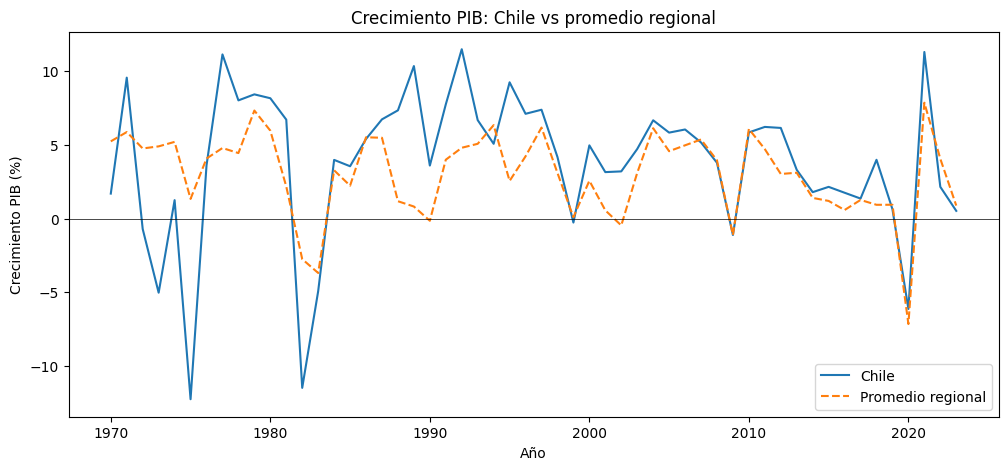

In [33]:
#Hipotesis 1 ¿Chile tuvo un crecimiento del PIB más estable que el promedio regional?
pib_chile = df[df['País'] == 'Chile'].groupby('Año')['crecimiento_pib'].mean()
pib_region = df.groupby('Año')['crecimiento_pib'].mean()
comp = pd.DataFrame({'Chile': pib_chile, 'Promedio regional': pib_region}).dropna()

plt.figure(figsize=(12, 5))
plt.plot(comp.index, comp['Chile'], label='Chile')
plt.plot(comp.index, comp['Promedio regional'], linestyle='--', label='Promedio regional')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Crecimiento PIB: Chile vs promedio regional')
plt.xlabel('Año')
plt.ylabel('Crecimiento PIB (%)')
plt.legend()
plt.show()

Vemos que las principales bajadas de PIB en Chile han sido en el 73', el 75', el 81' y el 2020. Todas calzan con periodos importantes, como Golpe Militar, Crisis de Petróleo y COVID-19

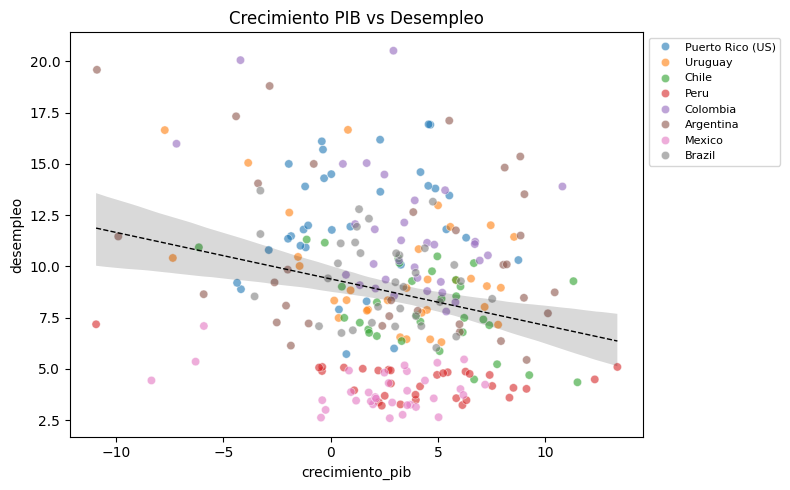

                 crecimiento_pib  desempleo
crecimiento_pib            1.000     -0.238
desempleo                 -0.238      1.000


In [39]:
#Hipotesis 2 ¿Existe una relación entre crecimiento del PIB y desempleo?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='crecimiento_pib', y='desempleo', hue='País', alpha=0.6)
plt.title('Crecimiento PIB vs Desempleo')
plt.xlabel('Crecimiento PIB (%)')
plt.ylabel('Desempleo (%)')
sns.regplot(data=df, x='crecimiento_pib', y='desempleo', 
            scatter=False, color='black', line_kws={'linewidth': 1, 'linestyle': '--'})
plt.legend(fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print(df[['crecimiento_pib', 'desempleo']].corr().round(3))

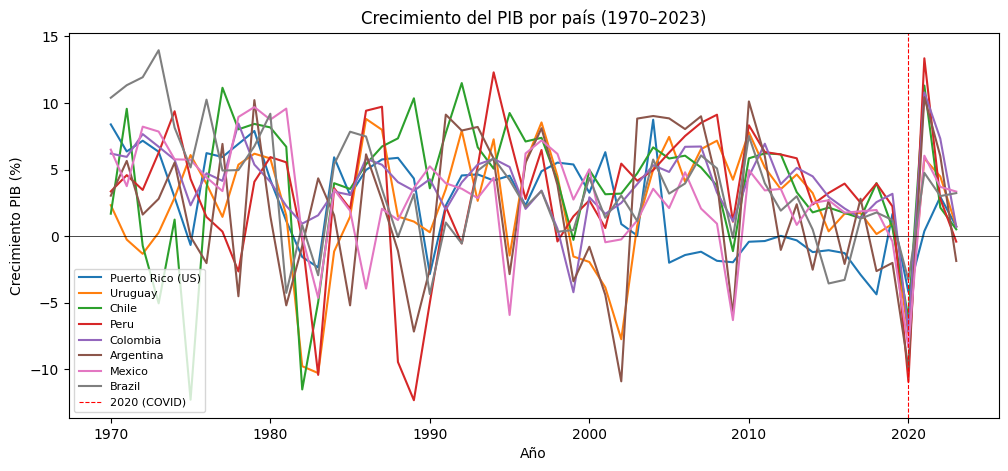

In [ ]:
#Hipotesis 3 y Pregunta 3 ¿COVID-19 afectó al mínimo del PIB o hubo un mínimo antes?
plt.figure(figsize=(12, 5))
for pais in df['País'].unique():
    datos = df[df['País'] == pais].sort_values('Año')
    plt.plot(datos['Año'], datos['crecimiento_pib'], label=pais)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(2020, color='red', linestyle='--', linewidth=0.8, label='2020 (COVID)')
plt.title('Crecimiento del PIB por país (1970–2023)')
plt.xlabel('Año')
plt.ylabel('Crecimiento PIB (%)')
plt.legend(fontsize=8)
plt.show()

Podemos ver que el mínimo del PIB en 2020 no fue el más bajo de la serie, pero si fue el que afectó a la región completa. El resto de mínimos, como los de 89' y del 82' fueron bajadas para la mayoría de países, pero no fue igual para todos (a diferencia del COVID-19).

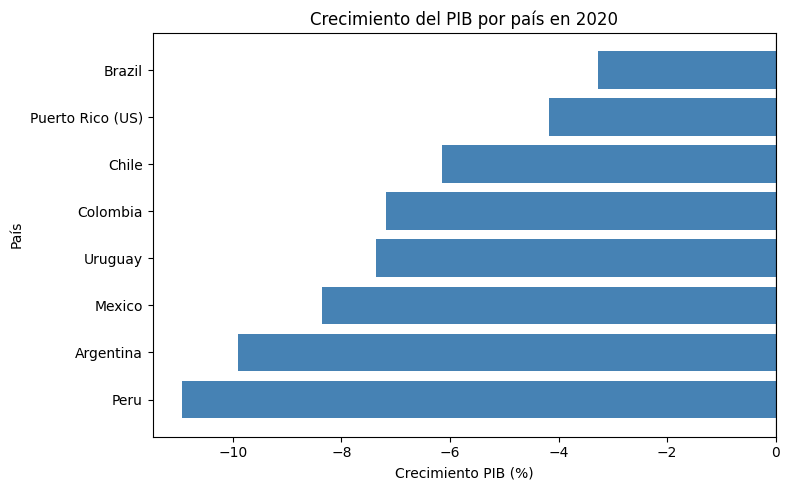

In [64]:
#Apoyo a Pregunta 3
pib_2020 = df[df['Año'] == 2020][['País', 'crecimiento_pib']].sort_values('crecimiento_pib')
plt.figure(figsize=(8, 5))
plt.barh(pib_2020['País'], pib_2020['crecimiento_pib'], color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Crecimiento del PIB por país en 2020')
plt.xlabel('Crecimiento PIB (%)')
plt.ylabel('País')
plt.tight_layout()
plt.show()

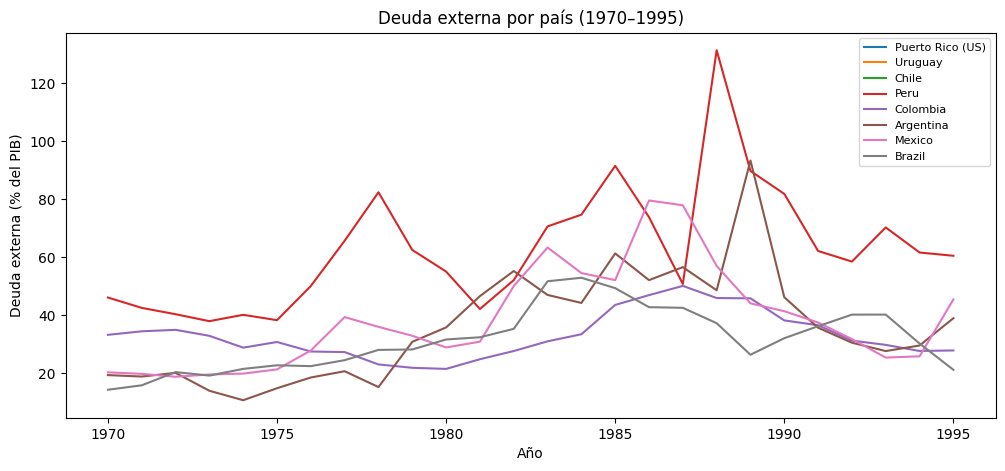

In [36]:
#Hipotesis 4 ¿La deuda externa aumentó significativamente en los años 70 y 95?
df_deuda = df[df['Año'] <= 1995]
plt.figure(figsize=(12, 5))
for pais in df_deuda['País'].unique():
    datos = df_deuda[df_deuda['País'] == pais].sort_values('Año')
    plt.plot(datos['Año'], datos['deuda_externa'], label=pais)
plt.title('Deuda externa por país (1970–1995)')
plt.xlabel('Año')
plt.ylabel('Deuda externa (% del PIB)')
plt.legend(fontsize=8)
plt.show()

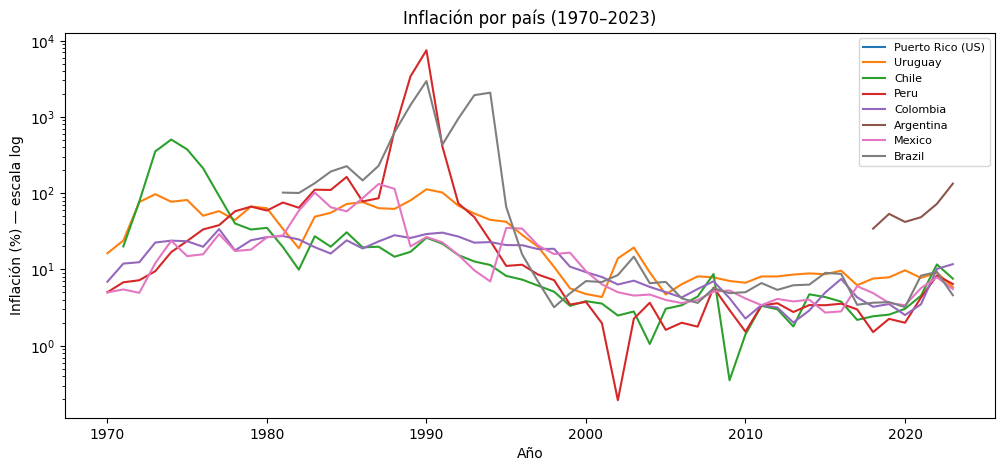

In [ ]:
#Pregunta 1 ¿Inflación máxima singular de países o general de la región?
plt.figure(figsize=(12, 5))
for pais in df['País'].unique():
    datos = df[df['País'] == pais].sort_values('Año')
    plt.plot(datos['Año'], datos['inflacion'], label=pais)
plt.yscale('log')
plt.title('Inflación por país (1970–2023)')
plt.xlabel('Año')
plt.ylabel('Inflación (%) — escala log')
plt.legend(fontsize=8)
plt.show()

Vemos que la mayor inflación corresponde a Perú y Brasil por los 90', seguido de Chile en los 70'

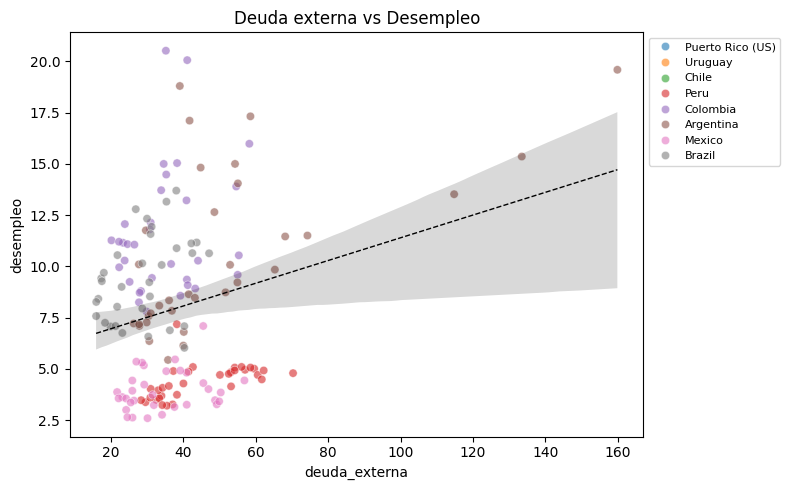

               deuda_externa  desempleo
deuda_externa          1.000      0.249
desempleo              0.249      1.000


In [ ]:
#Pregunta 2 ¿Existe relación entre deuda externa y desempleo?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='deuda_externa', y='desempleo', hue='País', alpha=0.6)
plt.title('Deuda externa vs Desempleo')
plt.xlabel('Deuda externa (% del PIB)')
plt.ylabel('Desempleo (%)')
sns.regplot(data=df, x='deuda_externa', y='desempleo', 
            scatter=False, color='black', line_kws={'linewidth': 1, 'linestyle': '--'})

plt.legend(fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


print(df[['deuda_externa', 'desempleo']].corr().round(3))

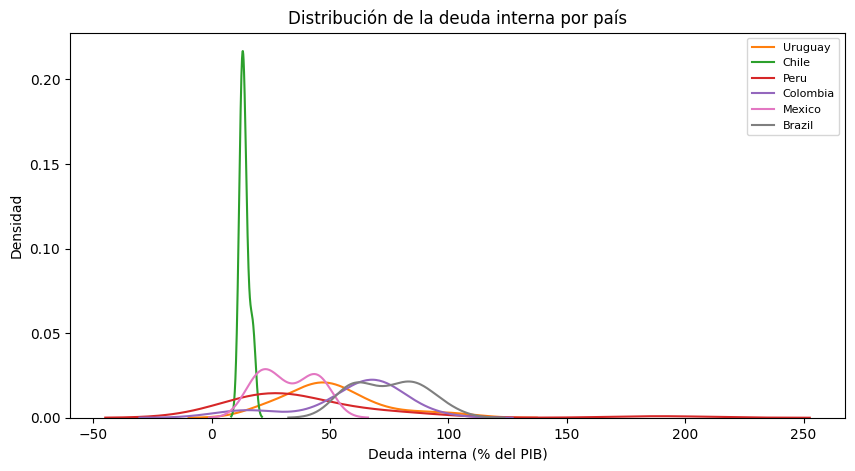

In [ ]:
#Distribución de la deuda interna por país para complementar información
plt.figure(figsize=(10, 5))
for pais in df['País'].unique():
    datos = df[df['País'] == pais]['deuda_interna'].dropna()
    sns.kdeplot(datos, label=pais)
plt.title('Distribución de la deuda interna por país')
plt.xlabel('Deuda interna (% del PIB)')
plt.ylabel('Densidad')
plt.legend(fontsize=8)
plt.show()

Parte 5: Interpretación de Resultados

Comenzaremos con las preguntas análiticas de la parte 3:

1. ¿La inflación extrema fue un fenómeno aisldo o regional?

El grafíco de inflación confirma que los valores extremos no corresponden a un solo país, aun que tampoco afectó a la región completa. Perú fue el caso mas extremo, con una inflación aproximada del 7000% por los 90's, el cual fue causado principalmente por la crisis económica del gobierno de Fujimori, además de la falta de pago de deuda externa y sobreimpresión de billetes. El otro país que se vió muy afectado en esta epoca fue Brasil con su inflación inercial e inestabilidad politica.
Esto responde a la pregunta, indicando que el fenómeno fue aislado, ya que, a pesar que afectó principalmente a 2 países, fueron causados por motivos distintos y que no afectó directamente a toda la región.

2. ¿Existe una correlación entre la deuda externa y el desempleo?

La correlación entre la deuda externa y el desempleo fue de *0.249*, lo que significa que tiene una relación positiva pero débil. Esto demuestra que, si bien existe una tendencia a "mayor deuda, mayor desempleo", no hay una relación lineal clara entre ambas variables. Además, esto se demuestra con el grafico, mostrando que, aun que hay una gran cantidad de datos reunido en cierta línea, hay muchos otros también que se salen del "rango esperado".

3. ¿El mínimo del PIB fue por COVID-19? ¿Y fue homogéneo?

El mínimo del PIB del dataset no fue producido por el COVID-19, ya que hubo un mínimo de PIB mayor en Perú (1989), sin embargo, el COVID-19 si produjo el mínimo del PIB promedio en la región, y fue totalmente homogéneo, ya que todos los países pasaron de un promedio del 1% de crecimiento del PIB en el 2019 a un -6% de crecimiento del PIB en el 2020. Todo esto lo vemos reflejado en los graficos de "Crecimiento del PIB por país (1970 - 2023)" y "Crecimiento PIB: Chile vs promedio general".


Ahora que terminamos de responder las preguntas análiticas, vamos con el contraste de los resultados con las hipotesis presentadas:

**Hipótesis Acertadas**
- La hipótesis sobre la inflación en Chile durante la primera mitad de los 70 se confirma. En el gráfico "Crecimiento PIB: Chile vs promedio regional" se ve que hay un peak visible alrededor de 1973 - 1974, consistente con el período previo y posterior al golpe militar. Además, podemos ver que el PIB en Chile ha seguido los mismos cambios que la región, pero hemos mantenido un PIB superior o igual al promedio de la región. 
- La correlación entre el PIB y desempleo tiene el signo correcto (inversamente proporcional).
- El COVID-19 efectivamente generó una caída regional en 2020 visible en todos los países, con recuperación que comenzó en 2021 en la región completa.

**Hipótesis a matizar o erroneas**
- Lo mas sorprendente fue el PIB en Chile en 2019, ya que uno esperaría que por el estallido social el PIB sufriría una caída notable, sin embargo, en el grafico se muestra que esa caída no fue tan distinguible. A aclarar este fenómeno, puede que sea porque el estallido social fue en el mes de Octubre, lo que probablemente generó que su repercusión se viera reflejada en el año 2020.
- La correlación de deuda externa con el desempleo resultó mas debil de lo esperado, con una correlación de *0.249*, lo que significa que la intuición no tiene un sustento estadístico tan directo, y que en realidad depende de otras variables, lo que imposibilita una correlación lineal simple.


Y para finalizar, encontramos principalmente 2 limitaciones con esta base de datos:

1. La deuda interna contiene una cantidad de data bastante pequeña y desigual entre países, lo que me prohibió usar otro tipo de graficos que muestre su información.
2. La información de inflación en Argentina está disponible solo desde el 2018 en adelante, por lo que no pudimos mostrar su inflación del 89', en donde alcanzaron una inflación del 3000%, la cual calza con la epoca en que Perú y Brasil alcanzaron su máximo de inflación también.